Data Download and Visualization

In [1]:
import xarray as xr
import numpy as np
dset = xr.open_dataset(r'D:\KAUST\semster2\geo_env_modelling\assignmnet5\GRIDSAT-B1.2009.11.25.06.v02r01.nc')

In [6]:
dset

<xarray.Dataset> Size: 401MB
Dimensions:        (time: 1, Ngeo: 6, lat: 2000, lon: 5143, sparse2ir: 2,
                    sparse2wv: 2, sparse2vs: 2, sparse3ir: 2)
Coordinates:
  * time           (time) datetime64[ns] 8B 2009-11-25T06:00:00
  * lat            (lat) float32 8kB -70.0 -69.93 -69.86 ... 69.79 69.86 69.93
  * lon            (lon) float32 21kB -180.0 -179.9 -179.9 ... 179.8 179.9 179.9
  * sparse2ir      (sparse2ir) int32 8B 0 1
  * sparse2wv      (sparse2wv) int32 8B 0 1
  * sparse2vs      (sparse2vs) int32 8B 0 1
  * sparse3ir      (sparse3ir) int32 8B 0 1
Dimensions without coordinates: Ngeo
Data variables: (12/25)
    satlat         (time, Ngeo) float32 24B ...
    satlon         (time, Ngeo) float32 24B ...
    satrad         (time, Ngeo) float32 24B ...
    satname        (time, Ngeo) |S50 300B ...
    b1ufile        (time, Ngeo) |S50 300B ...
    b1file         (time, Ngeo) |S50 300B ...
    ...             ...
    vschn_2        (time, lat, lon) float32 41MB ...
    satid_ir       (time, lat, lon) float32 41MB ...
    satid_wv       (time, lat, lon) int8 10MB ...
    satid_vs       (time, lat, lon) int8 10MB ...
    satid_ir3      (time, lat, lon) int8 10MB ...
    irwin_vza_adj  (time, lat, lon) float32 41MB ...
Attributes: (12/50)
    title:                      GridSat-B1 - Gridded Satellite (GridSat) ISCC...
    summary:                    Geostationary data are remapped to equal angl...
    Conventions:                CF-1.6
    Metadata_Conventions:       CF-1.6, Unidata Dataset Discovery v1.0, NOAA ...
    references:                 http://dx.doi.org/10.1175/2011BAMS3039.1  htt...
    source:                     ISCCP.B1U.a.FY2-C.2009.11.25.0600.CMA.gz,ISCC...
    ...                         ...
    _satid:                     _satid attributes are comma delimited arrays ...
    Satellite_Name_satid:       FY-2C,GOES-10,GOES-11,GOES-12,Meteosat-7,Mete...
    B1U_File_satid:             ISCCP.B1U.a.FY2-C.2009.11.25.0600.CMA.gz,ISCC...
    IRWIN_calibration_file:     b1u.calibration.correction.IRWIN.v17
    IRWVP_calibration_version:  v01
    Corrections:                IRWIN has VZA correction, All channels have p...

In [2]:
IR = np.array(dset.variables['irwin_cdr']).squeeze()
IR

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(2000, 5143), dtype=float32)

In [3]:
IR = np.flipud(IR)

In [4]:
IR = IR*0.01+200
IR = IR-273.15

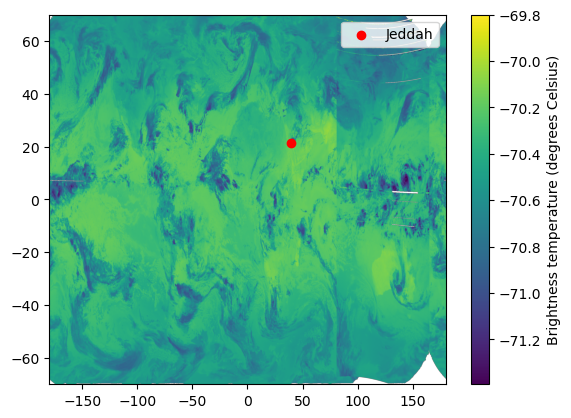

In [ ]:
import matplotlib.pyplot as plt
plt.figure(1)
plt.imshow(IR, extent=[-180.035, 180.035,-70.035, 70.035], aspect='auto')
cbar = plt.colorbar()
cbar.set_label('Brightness temperature (degrees Celsius)')
jeddah_lat = 21.5
jeddah_lon = 39.2

plt.scatter(jeddah_lon, jeddah_lat, label='Jeddah', color='red', marker='o')
plt.legend()
plt.savefig(r'D:\KAUST\semster2\geo_env_modelling\assignmnet5\IR_map.png', dpi=300)
plt.show()

In [13]:
import utils
import importlib
importlib.reload(utils)
from utils import load_dataset

min_file = load_dataset(path='D:\\KAUST\\semster2\\geo_env_modelling\\assignmnet5\\') # change to your path
print("Minimum BT file:", min_file)

Minimum BT file: D:\KAUST\semster2\geo_env_modelling\assignmnet5\GRIDSAT-B1.2009.11.25.06.v02r01.nc


Rainfall Estimation

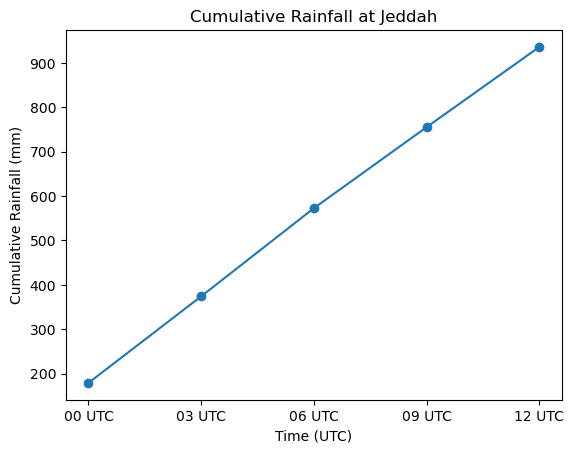

Maximum cumulative rainfall: D:\KAUST\semster2\geo_env_modelling\assignmnet5\GRIDSAT-B1.2009.11.25.06.v02r01.nc


In [21]:
import utils
import importlib
importlib.reload(utils)
from utils import plot_cumulative_rainfall

max_rainfall=plot_cumulative_rainfall(path='D:\\KAUST\\semster2\\geo_env_modelling\\assignmnet5\\')
print("Maximum cumulative rainfall:", max_rainfall)